<a href="https://colab.research.google.com/github/WellHelga/well_informatics/blob/main/Shielding(Usanova_Olga).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[ 15.56771828  15.6025449   15.63636017 ...  81.35712813 109.48451162
  80.67893879]


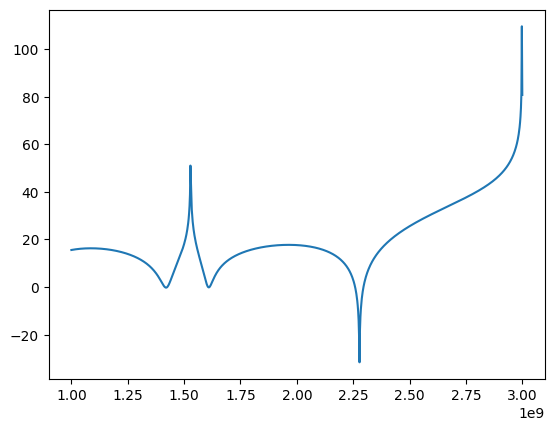

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calc_enclosure_se(freq, a, b, d, p, l, w, t):
    """
    Расчёт эффективности экранирования прямоугольного корпуса с апертурой.

    Параметры (размеры в метрах, частоты в Гц):
        freq — массив частот, Гц (numpy array)
        a    — ширина корпуса, м
        b    — высота корпуса, м
        d    — глубина корпуса, м
        l    — ширина апертуры, м
        w    — высота апертуры, м

    Возвращает:
        SE — массив эффективности экранирования, дБ (numpy array)
    """
    Z0 = 120.0 * np.pi
    c = 2.99792458e8
    v0 = complex(1.0, 0.0)

    m = 1

    we = w - (5 * t) / (4 * np.pi) * (1 + np.log((4 * np.pi * w) / t))
    ke = we / b

    K = np.pi * (np.log(
        2 * (1 + (1 - ke**2)**0.25) / (1 - (1 - ke**2)**0.25)
    ))**(-1)
    Z0s = 120.0 * np.pi * K

    SE = np.zeros(len(freq))

    for i, f in enumerate(freq):
        lamb = c / f
        k0 = 2 * np.pi / lamb

        Zap = 0.5 * (l / a) * 1j * Z0s * np.tan(k0 * l / 2)
        v1 = v0 * Zap / (Z0 + Zap)
        Z1 = Z0 * Zap / (Z0 + Zap)

        vpp = 0.0 + 0j

        for M in range(1, m + 1):
            N = 0
            arg = 1 - (M * lamb / (2 * a))**2 - (N * lamb / (2 * b))**2

            if arg <= 0:
                continue

            sqrt_arg = np.sqrt(arg + 0j)
            Zg = Z0 / sqrt_arg
            kg = k0 * sqrt_arg

            v2 = v1 / (np.cos(kg * p) + 1j * (Z1 / Zg) * np.sin(kg * p))
            Z2 = (Z1 + 1j * Zg * np.tan(kg * p)) / (1 + 1j * (Z1 / Zg) * np.tan(kg * p))
            Z3 = 1j * Zg * np.tan(kg * (d - p))

            vp = v2 * Z3 / (Z2 + Z3)
            vpp += vp

        if abs(vpp) > 0:
            SE[i] = -20 * np.log10(abs(2 * vpp / v0))
        else:
            SE[i] = 200.0

    return SE

a = 0.5
b = 0.3
d = 0.2
l = 0.1
w = 0.05
t = 0.01
p = 0.1

arr = np.array([[300], [60], [80], [90], [90], [60], [70]])
freq = np.linspace(1e9, 3e9, 1001)
SE = calc_enclosure_se(freq, a, b, d, p, l, w, t)
print(SE)
plt.plot(freq, SE,)
plt.show()